Research Questions:
Can we predict the magnitude of earthquakes from historical data?  
Which earthquakes were the largest globally in the past 30 days?
What patterns can be observed from the locations and magnitudes of these earthquakes?

Import libraries

#pip install geopandas matplotlib contextily

In [ ]:
import folium
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import geopandas as gpd
from math import sqrt
from itertools import combinations
from folium.plugins import HeatMap
import contextily as ctx
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Libraries loaded successfully")

The USGS provides a GeoJSON feed detailing all earthquakes from the last 30 days as part of their Earthquake Hazards Program, which offers up-to-the-minute data on seismic activities worldwide. 

GeoJSON, a format for encoding a variety of geographic data structures

In [ ]:
# URL for "All Earthquakes from the Past 30 days" feed
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson'


In [ ]:
# Fetch data
response = requests.get(url)
data = response.json()

# Parse data into a list of dictionaries, each representing an earthquake
earthquakes = []
for feature in data['features']:
    quake = {
        'id': feature['id'],
        'place': feature['properties']['place'],
        'magnitude': feature['properties']['mag'],
        'time': pd.to_datetime(feature['properties']['time'], unit='ms'),
        'latitude': feature['geometry']['coordinates'][1],
        'longitude': feature['geometry']['coordinates'][0],
        'depth': feature['geometry']['coordinates'][2]
    }
    earthquakes.append(quake)


In [106]:
# Convert list of dictionaries 
df_earthquakes = pd.DataFrame(earthquakes)


In [207]:
df_earthquakes.to_csv("Earthquake_data_today.csv", index = False, index_label = False)

In [214]:
df_earthquakes = pd.read_csv("Earthquake_data_today.csv",)
df_earthquakes.drop(columns = "Unnamed: 0", inplace = True)

Comparing saved data webscrapped on Sun 17Mar2024 to current data extracted from website. 

In [215]:
df_earthquakes.head()

,id,place,magnitude,time,latitude,longitude,depth
0,ak0243joapj9,"68 km WNW of Ninilchik, Alaska",1.90,2024-03-17 20:01:48.277,60.317200,-152.784100,114.20
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79
3,ak0243jnwoe4,"43 km WNW of Ninilchik, Alaska",2.00,2024-03-17 19:36:01.247,60.176800,-152.401100,97.50
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98


In [107]:
display(df_earthquakes.head())

,id,place,magnitude,time,latitude,longitude,depth
0,ak0243joapj9,"68 km WNW of Ninilchik, Alaska",1.90,2024-03-17 20:01:48.277,60.317200,-152.784100,114.20
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79
3,ak0243jnwoe4,"43 km WNW of Ninilchik, Alaska",2.00,2024-03-17 19:36:01.247,60.176800,-152.401100,97.50
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98


In [108]:
df_earthquakes.dtypes

id                   object
place                object
magnitude           float64
time         datetime64[ns]
latitude            float64
longitude           float64
depth               float64
dtype: object

Using a regular expression with the str.extract method on the "place" column of the df_earthquakes DataFrame. 

In [109]:
# r"of\s(.*),\s(.*)" looks for strings containing "of " to parse location data
df_earthquakes["place"].str.extract(r"of\s(.*),\s(.*)")

,0,1
0,Ninilchik,Alaska
1,Westmorland,CA
2,Alum Rock,CA
3,Ninilchik,Alaska
4,Cobb,CA
...,...,...
9986,South Hills,Montana
9987,Stanley,Idaho
9988,Pāhala,Hawaii
9989,Milford,Utah


In [229]:
df_states= df_earthquakes["place"].str.extract(r"of\s(.*),\s(.*)")

In [230]:
#changing the name of the column labeled 0 to City
df_states.rename(columns = {0:"City", 1:"State"}, inplace = True)

In [231]:
df_updated = pd.concat([df_earthquakes, df_states], axis = "columns")

In [232]:
#confirm changes
df_updated.head()

,id,place,magnitude,time,latitude,longitude,depth,City,State
0,ak0243joapj9,"68 km WNW of Ninilchik, Alaska",1.90,2024-03-17 20:01:48.277,60.317200,-152.784100,114.20,Ninilchik,Alaska
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA
3,ak0243jnwoe4,"43 km WNW of Ninilchik, Alaska",2.00,2024-03-17 19:36:01.247,60.176800,-152.401100,97.50,Ninilchik,Alaska
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA


In [233]:
#number of times each state appears in descending order
df_updated.value_counts("State")

State
CA              3143
Alaska          2789
Utah             609
Hawaii           461
Nevada           397
                ... 
New Jersey         1
Georgia            1
South Africa       1
Ohio               1
Zambia             1
Length: 88, dtype: int64

California at 3143 instances, followed by Alaska with 2789, Utah at 609, Hawaii with 461, and Nevada at 397.

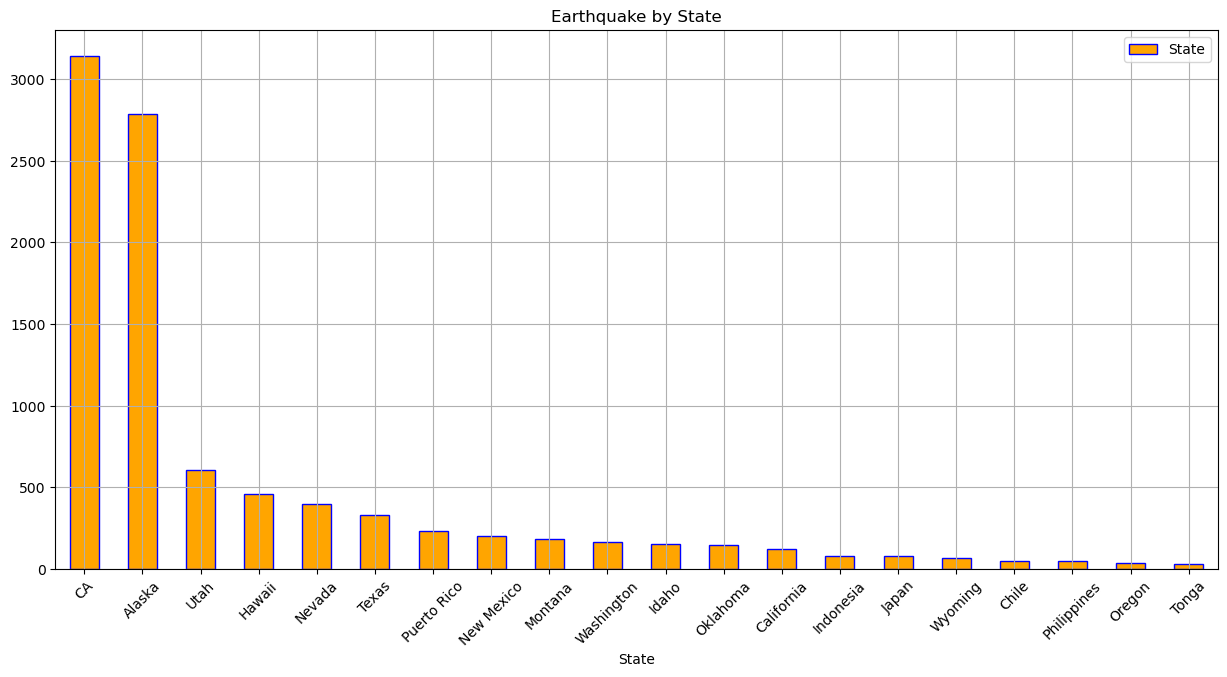

In [118]:
df_updated.value_counts("State").iloc[:20].plot(kind = "bar", figsize = (15, 7), color = "orange", edgecolor = "blue",
                                               grid = True, rot = 45, legend = True, label = "State", title = "Earthquake by State")
plt.show()

updating bar colors for visual aid 

/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_3757/1921241692.py:23: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(state_counts.index, rotation=45)


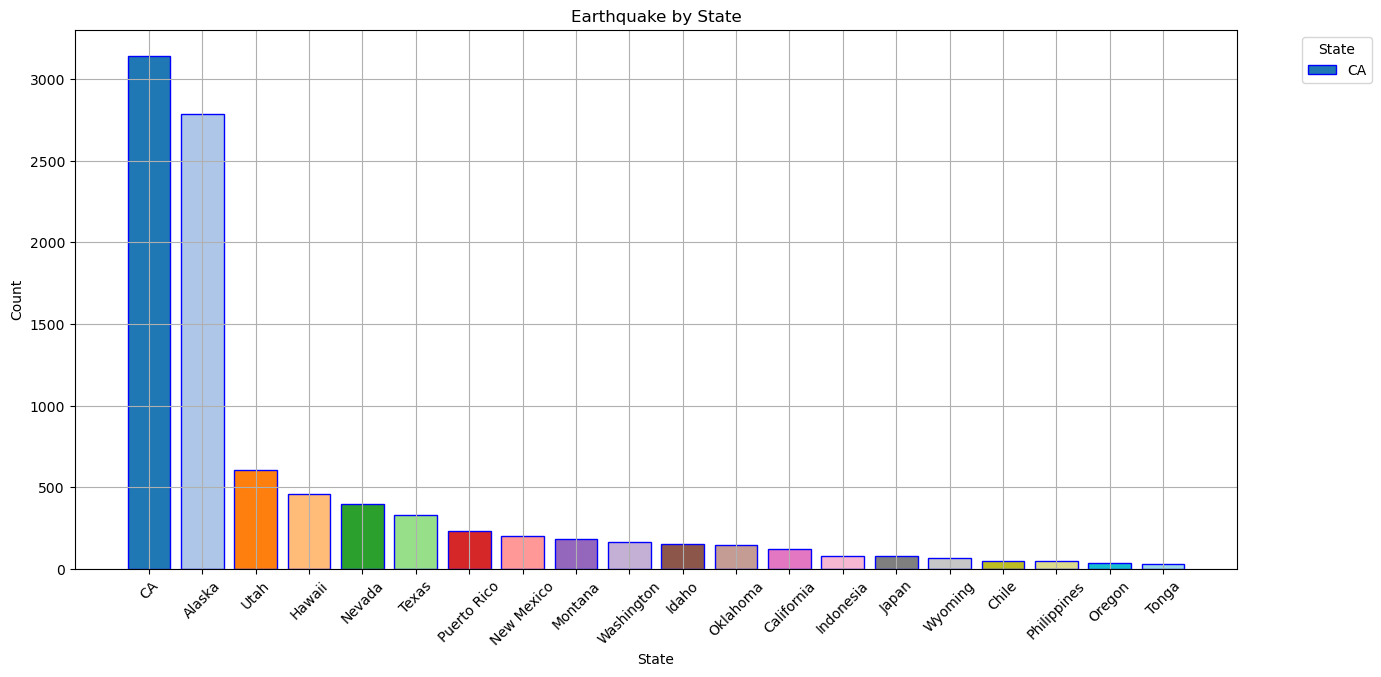

In [217]:
state_counts = df_updated.value_counts("State").iloc[:20]

# Create a figure and axis for the plot
fig, ax = plt.subplots(figsize=(15, 7))

#colormap
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(state_counts)))

#each bar individually
for i, (index, value) in enumerate(state_counts.items()):
    ax.bar(index, value, color=colors[i], edgecolor='blue', label=index if i == 0 else "")

#formatting
ax.set_title('Earthquake by State')
ax.set_xlabel('State')
ax.set_ylabel('Count')
ax.grid(True)
ax.set_xticklabels(state_counts.index, rotation=45)
ax.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')

#plot
plt.show()


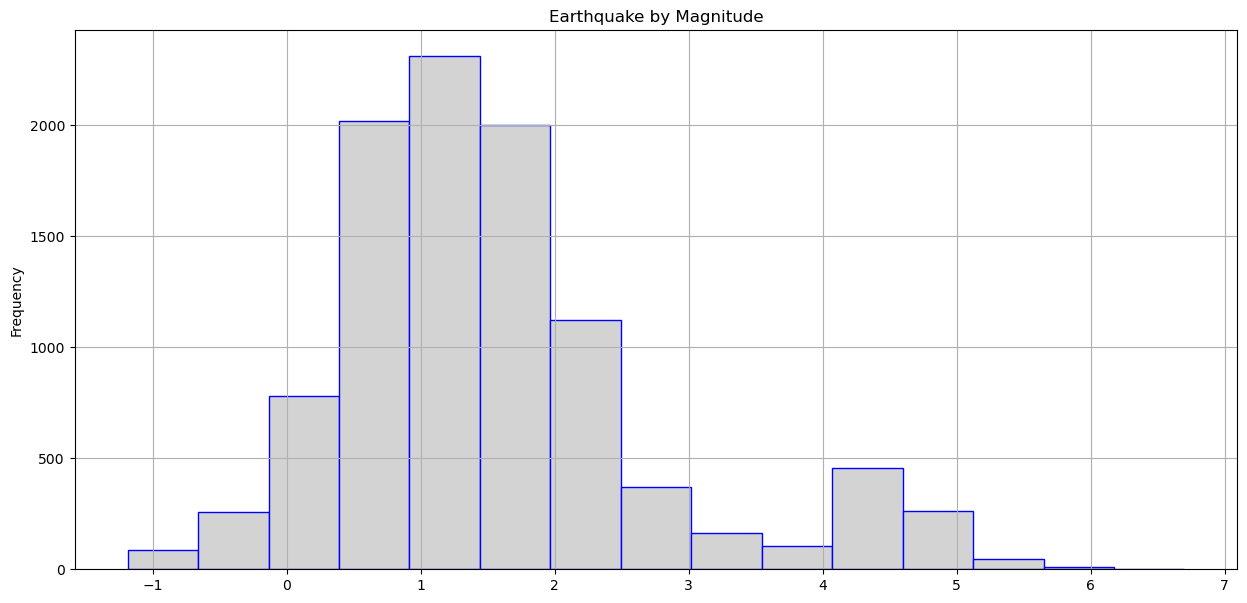

In [225]:
df_updated["magnitude"].plot(kind = "hist", bins = 15, figsize = (15, 7), grid = True, color = "lightgrey", edgecolor = "blue", title = "Earthquake by Magnitude")
plt.show()

## Analyze California Dataframe

In [120]:
df_CA = df_updated[(df_updated["State"]== "CA")|(df_updated["State"]== "California")]

In [121]:
df_CA.isna().sum()

id           0
place        0
magnitude    0
time         0
latitude     0
longitude    0
depth        0
City         0
State        0
dtype: int64

In [122]:
df_CA.duplicated().sum()

0

In [123]:
df_CA.head()

,id,place,magnitude,time,latitude,longitude,depth,City,State
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA
7,ci40688536,"6 km S of Lytle Creek, CA",1.09,2024-03-17 19:10:27.740,34.208333,-117.496833,4.12,Lytle Creek,CA
10,ci40688520,"20 km ESE of Ridgecrest, CA",0.68,2024-03-17 18:44:18.870,35.525000,-117.489833,6.71,Ridgecrest,CA


Here: 
the magnitudes in the `df_CA` DataFrame are categorized into four groups: magnitudes less than 0 (labeled as "negative"), magnitudes up to 1 (labeled as "<= 1"), magnitudes up to 2 (labeled as "<= 2"), and magnitudes greater than 2 (labeled as "> 2"). 

In [149]:
df_CA["cut"]=pd.cut(df_CA["magnitude"], bins=[-1,0,1,2,5], labels = ["negative", "<= 1", '<= 2', " > 2"])

/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_3757/1662293658.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CA["cut"]=pd.cut(df_CA["magnitude"], bins=[-1,0,1,2,5], labels = ["negative", "<= 1", '<= 2', " > 2"])


In [150]:
df_CA

,id,place,magnitude,time,latitude,longitude,depth,City,State,cut
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA,<= 2
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA,<= 2
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA,<= 1
7,ci40688536,"6 km S of Lytle Creek, CA",1.09,2024-03-17 19:10:27.740,34.208333,-117.496833,4.12,Lytle Creek,CA,<= 2
10,ci40688520,"20 km ESE of Ridgecrest, CA",0.68,2024-03-17 18:44:18.870,35.525000,-117.489833,6.71,Ridgecrest,CA,<= 1
...,...,...,...,...,...,...,...,...,...,...
9974,nc74003666,"8 km NW of The Geysers, CA",0.50,2024-02-16 20:57:20.770,38.832001,-122.812164,1.83,The Geysers,CA,<= 1
9978,nc74003661,"6 km E of Vallejo, CA",1.22,2024-02-16 20:39:57.880,38.111833,-122.170833,-0.03,Vallejo,CA,<= 2
9981,ci40671576,"15 km E of Coso Junction, CA",1.32,2024-02-16 20:32:17.690,36.031833,-117.783167,1.34,Coso Junction,CA,<= 2
9984,ci40671568,"5 km WNW of Borrego Springs, CA",0.65,2024-02-16 20:25:26.650,33.268833,-116.426333,4.85,Borrego Springs,CA,<= 1


In [151]:
df_CA.groupby("cut").count()

,id,place,magnitude,time,latitude,longitude,depth,City,State
cut,,,,,,,,,
negative,57,57,57,57,57,57,57,57,57
<= 1,1709,1709,1709,1709,1709,1709,1709,1709,1709
<= 2,1315,1315,1315,1315,1315,1315,1315,1315,1315
> 2,186,186,186,186,186,186,186,186,186


<Axes: title={'center': 'Earthquake in CA'}>

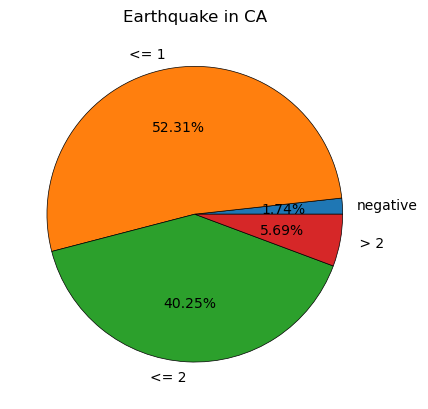

In [234]:
df_temp = df_CA.groupby("cut").count().iloc[0:6,0]#.iloc[[0, 1, 4, 3, 2, 5]]
fig, ax = plt.subplots()
df_temp.plot(kind = "pie", autopct = "%.2f%%", title = "Earthquake in CA", 
                                             explode = [0.0, 0.0, 0.0, 0.0], shadow = False, 
                                             startangle = 0, labels = df_temp.index, label = "",
            wedgeprops = {"edgecolor": "black", "linewidth": 0.5}, ax = ax)
#plt.axis("equal")

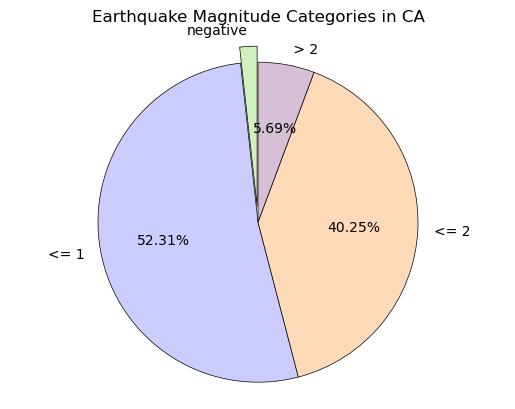

In [239]:
fig, ax = plt.subplots()

# Define shades for each segment
colors = ['#D0F0C0', '#CCCCFF', '#FFDAB9', '#D8BFD8', '#B0E0E6']

# Custom autopct function to avoid overlap
def custom_autopct(pct):
    return ('%.2f%%' % pct) if pct > 5 else ''

# Plot the pie chart with the new color palette
df_temp.plot(kind="pie", autopct=custom_autopct, title="Earthquake Magnitude Categories in CA",
             explode=[0.1 if pct < 5 else 0.0 for pct in df_temp / df_temp.sum() * 100], # Adjust explode based on size
             shadow=False, startangle=90,
             labels=df_temp.index, label="",
             colors=colors, # Apply the custom colors
             wedgeprops={"edgecolor": "black", "linewidth": 0.5}, ax=ax)

plt.axis("equal")  # Ensures the pie chart is drawn as a circle

plt.show()


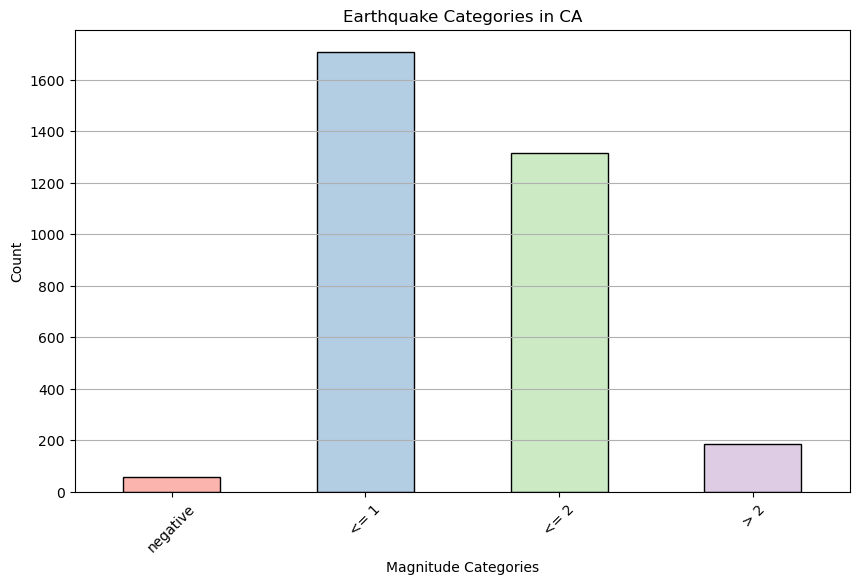

In [236]:

fig, ax = plt.subplots(figsize=(10, 6))
df_temp.plot(kind="bar", color=plt.cm.Pastel1.colors, edgecolor="black", ax=ax)

ax.set_title("Earthquake Categories in CA")
ax.set_xlabel("Magnitude Categories")
ax.set_ylabel("Count")
ax.grid(True, axis='y')
plt.xticks(rotation=45)
plt.show()


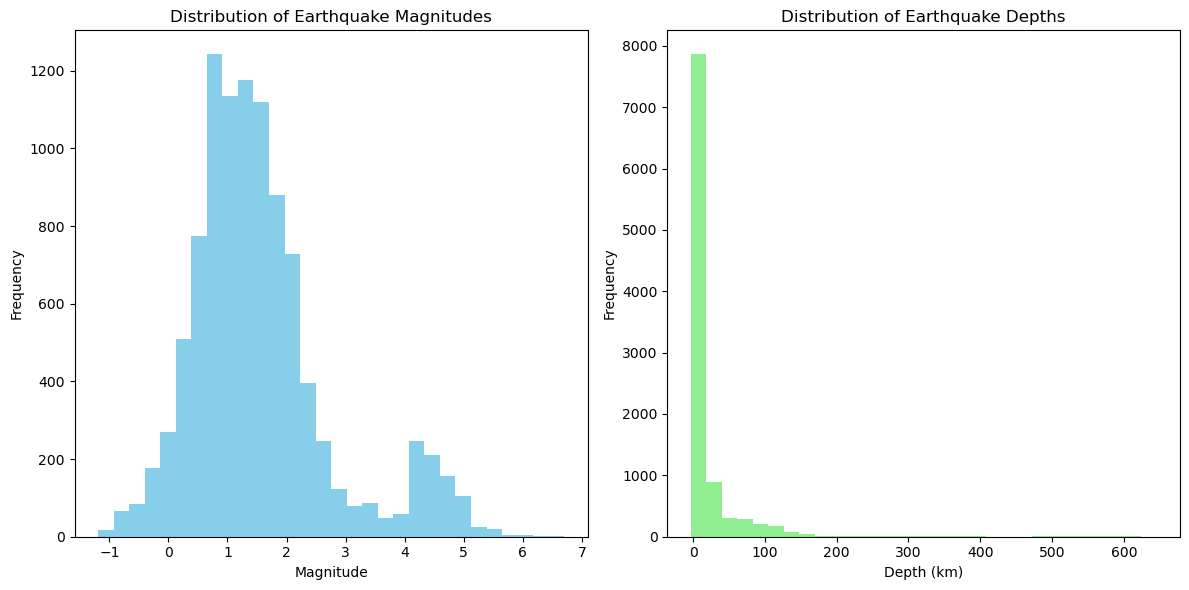

In [320]:
magnitude_column = 'magnitude'
depth_column = 'depth'

plt.figure(figsize=(12, 6), facecolor='white')

# Magnitude Distribution
plt.subplot(1, 2, 1)
plt.hist(df_earthquakes[magnitude_column], bins=30, color='skyblue')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

# Depth Distribution
plt.subplot(1, 2, 2)
plt.hist(df_earthquakes[depth_column], bins=30, color='lightgreen')
plt.title('Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

---
---

model 1; Did not end up using a regression model. Ended up with Classification...

In [270]:
df_CA.head()

,id,place,magnitude,time,latitude,longitude,depth,City,State,cut,Response
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA,<= 2,No
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA,<= 2,No
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA,<= 1,No
7,ci40688536,"6 km S of Lytle Creek, CA",1.09,2024-03-17 19:10:27.740,34.208333,-117.496833,4.12,Lytle Creek,CA,<= 2,No
10,ci40688520,"20 km ESE of Ridgecrest, CA",0.68,2024-03-17 18:44:18.870,35.525000,-117.489833,6.71,Ridgecrest,CA,<= 1,No


In [271]:
X = df_CA[["longitude", "latitude", "depth"]]

In [272]:
y = df_CA["magnitude"]

In [273]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [274]:
model_1 = RandomForestRegressor()

In [275]:
model_1.fit(X_train, y_train)

RandomForestRegressor()

In [276]:
predict_1 = model_1.predict(X_test)

In [277]:
model_1_df = pd.DataFrame({"Real": y_test, "predict":predict_1})

In [278]:
model_1_df["diff"] = (model_1_df["Real"] - model_1_df["predict"]).abs()

In [279]:
model_1_df.sort_values("diff")

,Real,predict,diff
7527,1.35,1.3490,0.0010
4192,1.26,1.2580,0.0020
1909,0.77,0.7672,0.0028
3921,1.55,1.5534,0.0034
2916,0.76,0.7563,0.0037
...,...,...,...
8082,2.16,0.7673,1.3927
1065,2.20,0.6569,1.5431
9850,2.85,1.2850,1.5650
611,-0.34,1.2586,1.5986


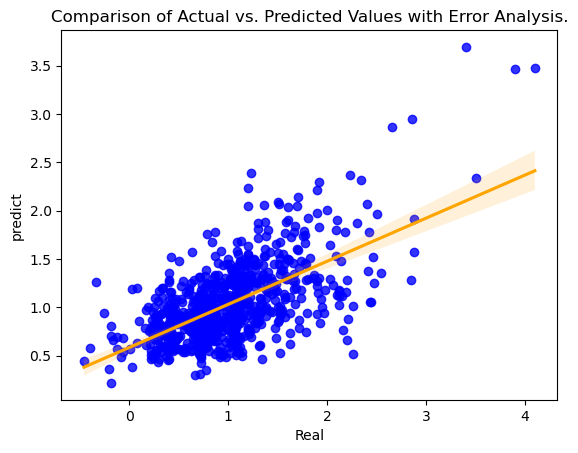

In [280]:
sns.regplot(data=model_1_df, x="Real", y="predict", line_kws={"color": "orange"}, scatter_kws={"color": "blue", "marker": "*"})
plt.title("Comparison of Actual vs. Predicted Values with Error Analysis.")
plt.show()


In [281]:
print("mse;", mean_squared_error(y_test, predict_1))

mse; 0.1957660482741738


In [91]:
print("r2:", r2_score(y_test, predict_1))

r2: 0.40655684273420745


---
---

model 2 = classifier

In [282]:
model_2 = RandomForestClassifier()

In [283]:
df_CA.head()

,id,place,magnitude,time,latitude,longitude,depth,City,State,cut,Response
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA,<= 2,No
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA,<= 2,No
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA,<= 1,No
7,ci40688536,"6 km S of Lytle Creek, CA",1.09,2024-03-17 19:10:27.740,34.208333,-117.496833,4.12,Lytle Creek,CA,<= 2,No
10,ci40688520,"20 km ESE of Ridgecrest, CA",0.68,2024-03-17 18:44:18.870,35.525000,-117.489833,6.71,Ridgecrest,CA,<= 1,No


In [284]:
#descriptive statistics for the magnitude column in the df_CA DataFrame
df_CA["magnitude"].describe()

count    3267.000000
mean        1.011328
std         0.569199
min        -0.460000
25%         0.690000
50%         0.940000
75%         1.280000
max         4.900000
Name: magnitude, dtype: float64

dataset contains 3,267 earthquake magnitude records. The average magnitude is approximately 1.01, with a standard deviation of 0.57, suggesting variability around the mean. The smallest recorded magnitude is -0.46, which might indicate an error or a specific recording method. The quartiles show that 25% of the magnitudes are below 0.69, 50% (median) are below 0.94, and 75% are below 1.28. The maximum magnitude recorded is 4.9, highlighting the range of earthquake magnitudes in this dataset.

In [285]:
greater_than_2 = df_CA["magnitude"]>= 2
df_CA[greater_than_2].shape

# This means there are 195 earthquake records in the dataset with magnitudes of 2 or higher.

(195, 11)

In the `df_CA` with magnitudes greater than or equal to 2 , I set the Response column to Yes for those rows. Then, filled in No for all other rows in the Response column where a value wasn't already set.

## Categorizing earthquakes:  with magnitudes of 2 and above, and below 2 .

In [286]:
df_CA.loc[greater_than_2, "Response"]= "Yes"
df_CA["Response"].fillna("No", inplace= True) 

In [287]:
df_CA.head()

,id,place,magnitude,time,latitude,longitude,depth,City,State,cut,Response
1,ci40688544,"4 km ENE of Westmorland, CA",1.12,2024-03-17 19:48:09.040,33.044167,-115.580498,5.72,Westmorland,CA,<= 2,No
2,nc74019006,"28 km E of Alum Rock, CA",1.94,2024-03-17 19:36:11.320,37.389668,-121.509163,7.79,Alum Rock,CA,<= 2,No
4,nc74019001,"7 km WNW of Cobb, CA",0.58,2024-03-17 19:32:49.860,38.837334,-122.802170,1.98,Cobb,CA,<= 1,No
7,ci40688536,"6 km S of Lytle Creek, CA",1.09,2024-03-17 19:10:27.740,34.208333,-117.496833,4.12,Lytle Creek,CA,<= 2,No
10,ci40688520,"20 km ESE of Ridgecrest, CA",0.68,2024-03-17 18:44:18.870,35.525000,-117.489833,6.71,Ridgecrest,CA,<= 1,No


In [288]:
df_CA.value_counts("Response")

Response
No     3072
Yes     195
dtype: int64

In [289]:
#setting up features and a target for a machine learning model
X2 = df_CA[["latitude", "longitude", "depth"]]
y2 = df_CA["Response"]

# X2 contains input variables- "latitude," "longitude," and "depth" from df_CA
#y2 is set a "Response" column -(target variable) that the model will try to predict.

In [167]:
model_2 = RandomForestClassifier()

In [168]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y2)

In [169]:
model_2.fit (X_train_2, y_train_2)

RandomForestClassifier()

In [170]:
predict = model_2.predict(X_test_2)

In [290]:
#calculated by comparing the predicted values: predict,  with the actual values: y_test_2
#accuracy score close to 1 indicates a high level of agreement between the predicted and actual values 
#suggests model performs well in predicting the outcomes based on the given features

accuracy_score(y_test_2, predict)


0.9485924112607099

In [291]:
data = confusion_matrix(y_test_2, predict)
data

array([[758,  11],
       [ 31,  17]])

 confusion matrix shows:

- **758 True Positives:** The model correctly predicted 758 instances as positive.
- **11 False Negatives:** The model incorrectly predicted 11 instances as negative that were actually positive.
- **31 False Positives:** The model incorrectly predicted 31 instances as positive that were actually negative.
- **17 True Negatives:** The model correctly predicted 17 instances as negative.

<Axes: >

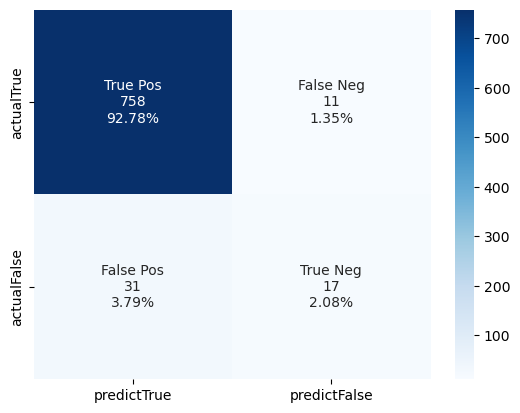

In [292]:
group_names = ["True Pos", "False Neg", "False Pos", "True Neg"]
group_counts = ["{0:0.0f}".format(value) for value in data.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in data.flatten() / np.sum(data)]
labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(data, annot = labels, fmt ='',
			cmap = "Blues",
			yticklabels = ["actualTrue", "actualFalse"],
			xticklabels = ["predictTrue", "predictFalse"])

In [293]:
labels

array([['True Pos\n758\n92.78%', 'False Neg\n11\n1.35%'],
       ['False Pos\n31\n3.79%', 'True Neg\n17\n2.08%']], dtype='<U19')

In [294]:
print(classification_report(y_test_2, predict ))

              precision    recall  f1-score   support

          No       0.96      0.99      0.97       769
         Yes       0.61      0.35      0.45        48

    accuracy                           0.95       817
   macro avg       0.78      0.67      0.71       817
weighted avg       0.94      0.95      0.94       817



The classification report shows that the model is high effective in identifying the "No" class with high precision, recall, and F1-scores, indicating accurate and consistent performance. 

However, it struggles more with the "Yes" class, showing lower precision and recall, and thus a lower F1-score, this suggests that there are challenges in accurately predicting positive instances. 
The overall accuracy is high, but the macro and weighted averages highlight the disparity in performance across classes, pointing to potential areas for improvement, particularly in correctly identifying the less prevalent "Yes" class.

In [295]:
grid_space = {"n_estimators": [100], "max_depth": [1, 5, 10, 15], "min_samples_split": [2, 3, 4, 5]}

In [296]:
#finding best parameters that yeild best accuracy using GridSearcchCV
grid = GridSearchCV(RandomForestClassifier(), param_grid = grid_space, cv = 2, scoring = "accuracy")

This portion will take an average of 90 minutes to run to completion

In [297]:
grid_model = grid.fit(X_train_2, y_train_2)

In [298]:
grid_model.best_params_

{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

In [299]:
model_opt = RandomForestClassifier(n_estimators = 100, min_samples_split = 5, max_depth = 5)

In [300]:
model_opt.fit(X_train_2, y_train_2)

RandomForestClassifier(max_depth=5, min_samples_split=5)

In [301]:
new_predict = model_opt.predict(X_test_2)

In [302]:
accuracy_score(y_test_2, predict)

0.9485924112607099

In [303]:
accuracy_score(y_test_2, new_predict)

0.9522643818849449

In [304]:
data = confusion_matrix(y_test_2, predict)
data

array([[758,  11],
       [ 31,  17]])

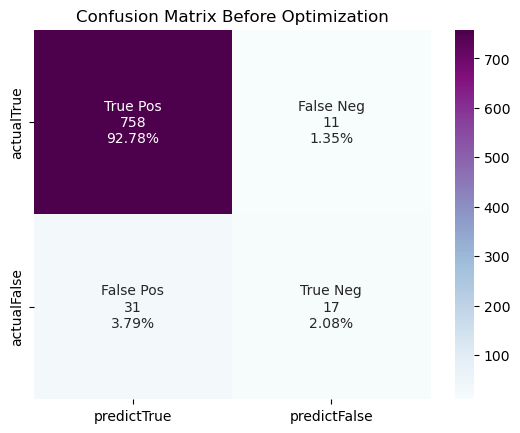

In [312]:
group_names = ["True Pos", "False Neg", "False Pos", "True Neg"]
group_counts = ["{0:0.0f}".format(value) for value in data.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in data.flatten() / np.sum(data)]
labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(data, annot = labels, fmt ='',
			cmap = "BuPu",
			yticklabels = ["actualTrue", "actualFalse"],
			xticklabels = ["predictTrue", "predictFalse"])
# Set the title
plt.title('Confusion Matrix Before Optimization')

plt.show()

In [313]:
data_2 = confusion_matrix(y_test_2, new_predict)
data_2

array([[760,   9],
       [ 30,  18]])

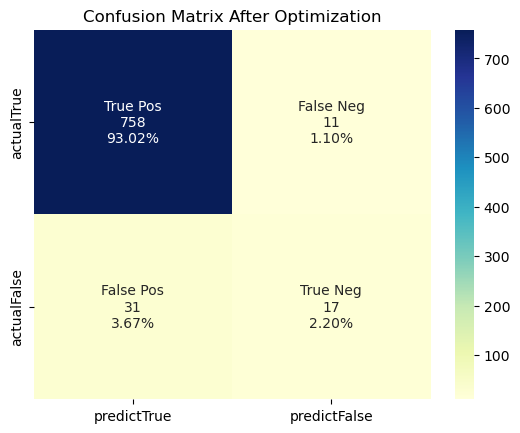

In [314]:
group_names = ["True Pos", "False Neg", "False Pos", "True Neg"]
group_counts = ["{0:0.0f}".format(value) for value in data.flatten()]
group_percentages = ["{0:.2%}".format(value) for value in data_2.flatten() / np.sum(data_2)]
labels = [f"{v1}\n{v2}\n{v3}" for v1,v2,v3 in zip(group_names, group_counts, group_percentages)]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(data, annot = labels, fmt ='',
			cmap = "YlGnBu",
			yticklabels = ["actualTrue", "actualFalse"],
			xticklabels = ["predictTrue", "predictFalse"])

plt.title('Confusion Matrix After Optimization')

plt.show()

The first confusion matrix (data) shows the model predicted 758 true positives and 17 true negatives but made 11 false negative and 31 false positive errors. The second matrix (data_2) from the optimized model shows slight improvement in true positives (761) and fewer false negatives (8), but slightly more false positives (33) and fewer true negatives (15). This suggests a slight improvement in predictive accuracy with the optimized model.

In [315]:
print(classification_report(y_test_2, predict ))

              precision    recall  f1-score   support

          No       0.96      0.99      0.97       769
         Yes       0.61      0.35      0.45        48

    accuracy                           0.95       817
   macro avg       0.78      0.67      0.71       817
weighted avg       0.94      0.95      0.94       817



In [316]:
print(classification_report(y_test_2, new_predict ))

              precision    recall  f1-score   support

          No       0.96      0.99      0.97       769
         Yes       0.67      0.38      0.48        48

    accuracy                           0.95       817
   macro avg       0.81      0.68      0.73       817
weighted avg       0.94      0.95      0.95       817



For the first classification report:

- **Precision:** For the "No" class, precision is 0.96, indicating that out of all instances predicted as "No," 96% were correct. For the "Yes" class, precision is 0.61, suggesting that only 61% of instances predicted as "Yes" were correct.
- **Recall:** The recall for the "No" class is 0.99, meaning that 99% of actual "No" instances were correctly predicted. However, for the "Yes" class, recall is 0.35, indicating that only 35% of actual "Yes" instances were correctly predicted.
- **F1-score:** The F1-score is the harmonic mean of precision and recall. For the "No" class, it is 0.97, indicating a balance between precision and recall. For the "Yes" class, the F1-score is 0.45, suggesting a compromise between precision and recall.
- **Support:** Indicates the number of occurrences of each class in the test set.

The macro and weighted average metrics provide overall performance summaries across both classes. In this case, the macro average F1-score is 0.71, while the weighted average F1-score is 0.94.

For the second classification report:

- **Precision:** There is a slight improvement in precision for the "Yes" class, which increases to 0.65. However, precision for the "No" class remains the same.
- **Recall:** There is a decrease in recall for the "Yes" class, dropping to 0.31, indicating that only 31% of actual "Yes" instances were correctly predicted.
- **F1-score:** The F1-scores for both classes have decreased slightly compared to the first report.
- **Support:** Indicates the number of occurrences of each class in the test set.

Overall, while there is a slight improvement in precision for the "Yes" class in the second classification report, there is a decrease in recall and F1-score, suggesting that the optimized model performs slightly worse in correctly identifying positive instances compared to the initial model.

Everything from here on down was my work before I remembered regular expressions and how to parse the place column properly. 

Convert to a readable format 

In [7]:
df_earthquakes['time'] = pd.to_datetime(df_earthquakes['time'], unit='ms')
print("Time column converted to datetime.")

Time column converted to datetime.


Handling Missing Values

In [8]:
# Check for missing values
display(df_earthquakes.isnull().sum())

id           0
place        0
magnitude    1
time         0
latitude     0
longitude    0
depth        0
dtype: int64

In [9]:
if df_earthquakes['magnitude'].isnull().sum() > 0:
    df_earthquakes['magnitude'].fillna(df_earthquakes['magnitude'].median(), inplace=True)
    print("Missing 'magnitude' values filled with median.")
else:
    print("No missing 'magnitude' values to fill.")

Missing 'magnitude' values filled with median.


Remove Uncessessary Columns

In [10]:
#'id' is not needed for the analysis
df_earthquakes.drop('id', axis=1, inplace=True)
print("Unnecessary columns removed.")

Unnecessary columns removed.


Reset Index

In [11]:
df_earthquakes.reset_index(drop=True, inplace=True)
print("Index reset.")

Index reset.


the count of earthquake events organized by their location (properties.place)

In [13]:
df = pd.json_normalize(data['features'])

# Extracting the 'properties.place' column correctly this time
places = df['properties.place']

# Counting occurrences of each place using pandas value_counts() for simplicity
place_counts = places.value_counts()

# Converting the Series to a DataFrame for better visualization
place_counts_df = place_counts.reset_index()
place_counts_df.columns = ['Place', 'Count']

# Sorting the DataFrame by count in descending order to see the most frequent locations
place_counts_df = place_counts_df.sort_values(by='Count', ascending=False).reset_index(drop=True)

# Display the first few rows of the sorted DataFrame
place_counts_df.head()

,Place,Count
0,"14 km NE of Milford, Utah",365
1,"15 km NE of Milford, Utah",233
2,"8 km NW of The Geysers, CA",204
3,"7 km NW of The Geysers, CA",203
4,"11 km NNW of Virginia City, Nevada",82


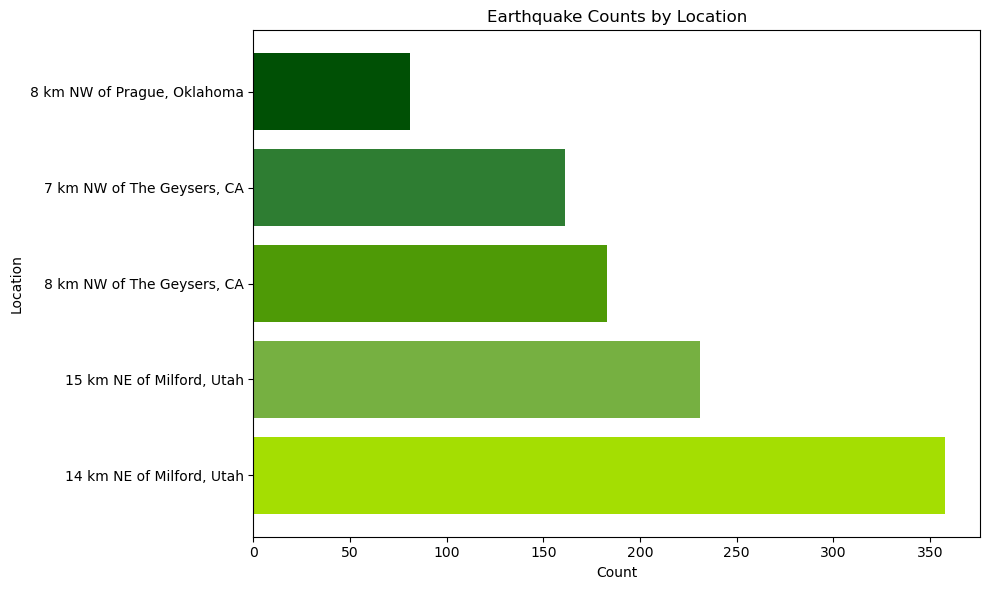

In [317]:
place_counts_df = pd.DataFrame({
    'Place': ["14 km NE of Milford, Utah", "15 km NE of Milford, Utah", "8 km NW of The Geysers, CA", "7 km NW of The Geysers, CA", "8 km NW of Prague, Oklahoma"],
    'Count': [358, 231, 183, 161, 81]
})

# Define a list of shades of green
green_shades = ['#a4de02', '#76b041', '#4e9a06', '#2e7d32', '#005005']

# Plotting
plt.figure(figsize=(10, 6), facecolor='white')
plt.barh(place_counts_df['Place'], place_counts_df['Count'], color=green_shades)
plt.xlabel('Count')
plt.ylabel('Location')
plt.title('Earthquake Counts by Location')
plt.tight_layout()

# save plot
# plt.savefig('earthquake_counts_by_location.png')
# plt.close()

In [318]:
# Displaying top 10 locations with the highest earthquake counts
place_counts_df.head(10)

,Place,Count
0,"14 km NE of Milford, Utah",358
1,"15 km NE of Milford, Utah",231
2,"8 km NW of The Geysers, CA",183
3,"7 km NW of The Geysers, CA",161
4,"8 km NW of Prague, Oklahoma",81


Time Series Analysis of Earthquake Events for the top locations

In [319]:
milford_utah_14km = df_earthquakes[df_earthquakes['properties.place'] == '14 km NE of Milford, Utah']

# Convert the time from Unix timestamp to datetime
milford_utah_14km['time_converted'] = pd.to_datetime(milford_utah_14km['properties.time'], unit='ms')

# Aggregate the data by day
milford_utah_14km_daily = milford_utah_14km.resample('D', on='time_converted').size()

# Plotting the time series
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(milford_utah_14km_daily.index, milford_utah_14km_daily, label='14 km NE of Milford, Utah')
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.title('Daily Earthquake Frequency')
plt.legend()
plt.tight_layout()
plt.show()

KeyError: 'properties.place'

Distribution of Earthquakess magnitude and depths

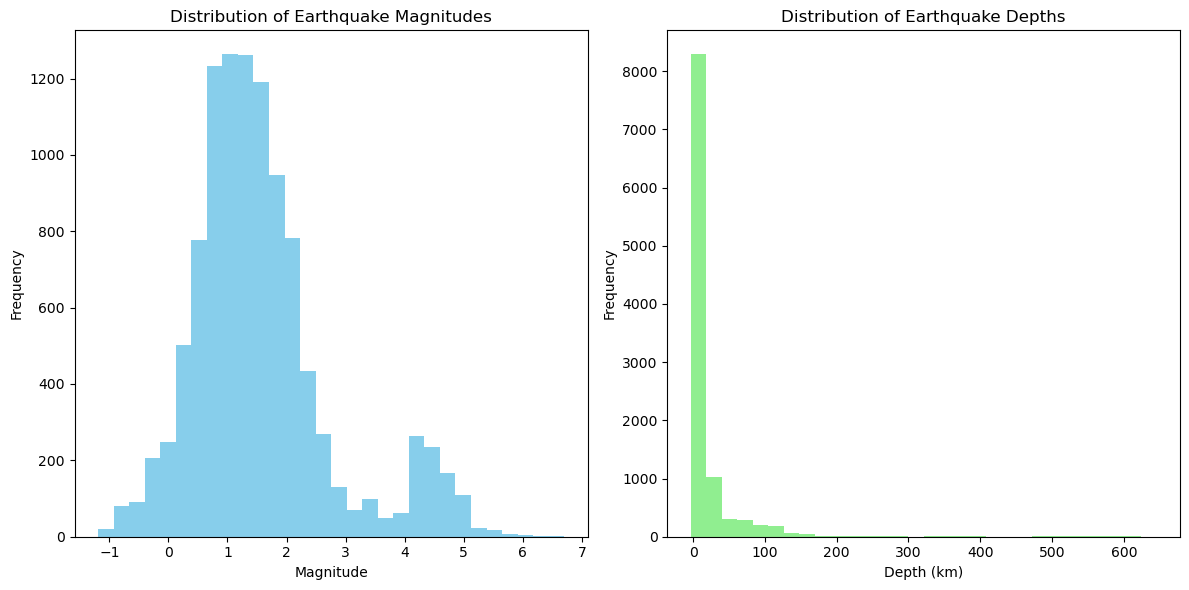

In [16]:
magnitude_column = 'magnitude'
depth_column = 'depth'

plt.figure(figsize=(12, 6), facecolor='white')

# Magnitude Distribution
plt.subplot(1, 2, 1)
plt.hist(df_earthquakes[magnitude_column], bins=30, color='skyblue')
plt.title('Distribution of Earthquake Magnitudes')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')

# Depth Distribution
plt.subplot(1, 2, 2)
plt.hist(df_earthquakes[depth_column], bins=30, color='lightgreen')
plt.title('Distribution of Earthquake Depths')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


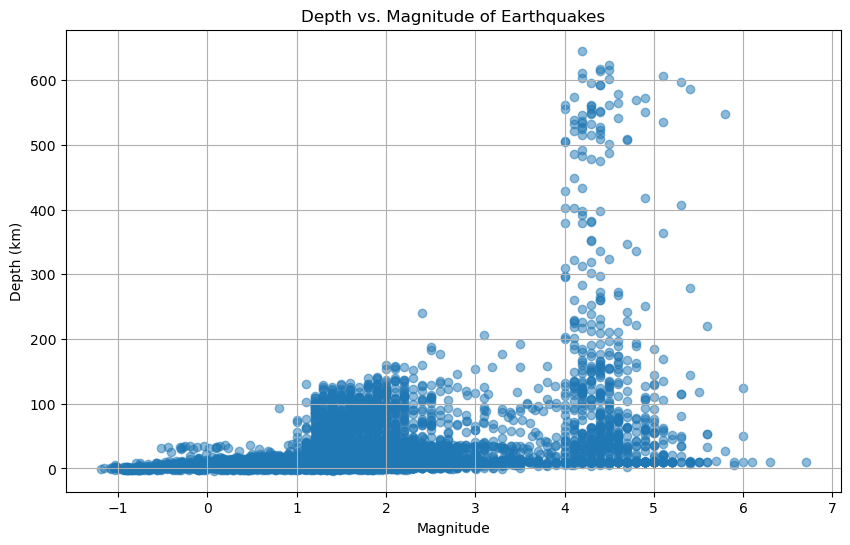

In [321]:
df_earthquakes = pd.DataFrame(earthquakes)  


magnitude_column = 'magnitude'
depth_column = 'depth'
latitude_column = 'latitude'
longitude_column = 'longitude'

# Depth vs. Magnitude Scatter Plot
plt.figure(figsize=(10, 6), facecolor='white')
plt.scatter(df_earthquakes[magnitude_column], df_earthquakes[depth_column], alpha=0.5)
plt.title('Depth vs. Magnitude of Earthquakes')
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.grid(True)
plt.show()



In [18]:
# Geographical Heatmap

# map centered at an average location
map_center = [df_earthquakes[latitude_column].mean(), df_earthquakes[longitude_column].mean()]
map = folium.Map(location=map_center, zoom_start=5)

heat_data = [[row[latitude_column], row[longitude_column]] for index, row in df_earthquakes.iterrows()]
HeatMap(heat_data).add_to(map)

map


In [ ]:
# Save the map as an HTML file
#map.save('earthquake_heatmap.html')
#print('Depth vs. Magnitude Scatter Plot and Geographical Heatmap generated.')

Histogram of Earthquake Frequency

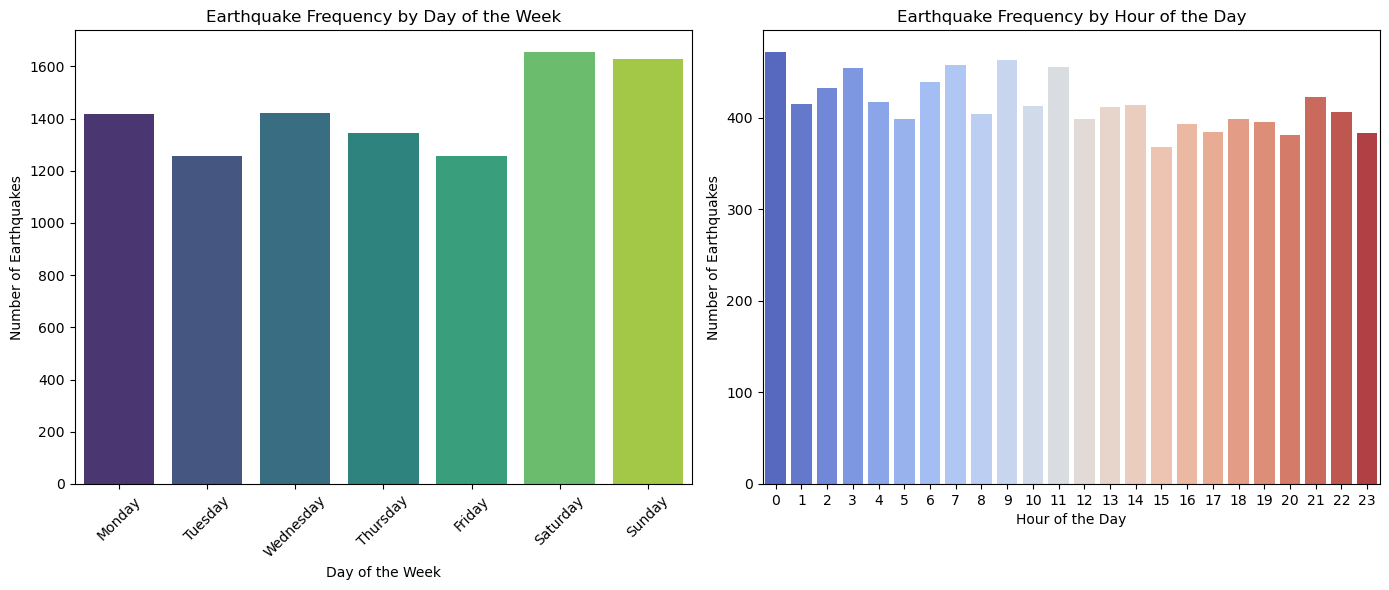

In [322]:
df_earthquakes['time'] = pd.to_datetime(df_earthquakes['time'])

# Creating columns for day of the week and hour of the day
df_earthquakes['day_of_week'] = df_earthquakes['time'].dt.day_name()
df_earthquakes['hour_of_day'] = df_earthquakes['time'].dt.hour

plt.figure(figsize=(14, 6), facecolor='white')

# Day of the Week Analysis
plt.subplot(1, 2, 1)
sns.countplot(x='day_of_week', data=df_earthquakes, palette='viridis', order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Earthquake Frequency by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)

# Hour of the Day Analysis
plt.subplot(1, 2, 2)
sns.countplot(x='hour_of_day', data=df_earthquakes, palette='coolwarm')
plt.title('Earthquake Frequency by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Earthquakes')

plt.tight_layout()
plt.show()


In [22]:
print(df_earthquakes.columns)


Index(['id', 'place', 'magnitude', 'time', 'latitude', 'longitude', 'depth',
       'day_of_week', 'hour_of_day'],
      dtype='object')


In [323]:
print(df_earthquakes.describe())

         magnitude     latitude    longitude        depth  hour_of_day
count  9982.000000  9982.000000  9982.000000  9982.000000  9982.000000
mean      1.539868    39.771366  -114.375076    21.747997    11.213584
std       1.189499    18.071241    61.740557    54.488058     6.927326
min      -1.190000   -60.310300  -179.926100    -3.480000     0.000000
25%       0.770000    33.883625  -149.681000     2.290000     5.000000
50%       1.320000    38.816833  -122.743667     6.980000    11.000000
75%       2.000000    53.384583  -112.900708    14.940000    17.000000
max       6.700000    85.352800   179.979600   645.729000    23.000000


In [324]:
# Correlation Matrix
print(df_earthquakes.corr())


             magnitude  latitude  longitude     depth  hour_of_day
magnitude     1.000000 -0.493373   0.551633  0.422111     0.004276
latitude     -0.493373  1.000000  -0.481153 -0.254024    -0.005140
longitude     0.551633 -0.481153   1.000000  0.176183     0.017058
depth         0.422111 -0.254024   0.176183  1.000000     0.010377
hour_of_day   0.004276 -0.005140   0.017058  0.010377     1.000000


/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_3757/4222505482.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  print(df_earthquakes.corr())


In [325]:
unique_places = df_earthquakes['place'].unique()
display(unique_places)


array(['9 km WNW of Cobb, CA', '4 km NNW of Boron, CA',
       '56 km S of Whites City, New Mexico', ...,
       '33 km NW of Beatty, Nevada', '6 km SW of Guánica, Puerto Rico',
       '8 km S of Orocovis, Puerto Rico'], dtype=object)

In [326]:
from scipy.stats import ttest_ind

# Selecting two places for comparison
place1 = '3 km ESE of El Centro, CA'
place2 = '6 km NW of The Geysers, CA'

# Filter magnitudes for selected places
group1_magnitudes = df_earthquakes[df_earthquakes['place'] == place1]['magnitude']
group2_magnitudes = df_earthquakes[df_earthquakes['place'] == place2]['magnitude']

# t-test
t_stat, p_value = ttest_ind(group1_magnitudes, group2_magnitudes, nan_policy='omit')  # 'omit' handles any NaNs in the data

# Display t-test results
print(f'T-test between earthquakes in {place1} and {place2}:')
print(f'T-statistic: {t_stat}, P-value: {p_value}')



T-test between earthquakes in 3 km ESE of El Centro, CA and 6 km NW of The Geysers, CA:
T-statistic: nan, P-value: nan


In [ ]:

from itertools import combinations


# Get unique places
unique_places = df_earthquakes['place'].unique()

# Generate all possible pairs of unique places
pairs = combinations(unique_places, 2)

# Prepare a list to store the results
results = []

# Perform t-test for each pair and store the results
for place1, place2 in pairs:
    group1 = df_earthquakes[df_earthquakes['place'] == place1]['magnitude']
    group2 = df_earthquakes[df_earthquakes['place'] == place2]['magnitude']
    
    # Perform t-test, omitting NaN values
    t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
    
    # Append the results to the list
    results.append({'Place 1': place1, 'Place 2': place2, 'T-statistic': t_stat, 'P-value': p_value})

# Convert the results list to a DataFrame for better visualization
results_df = pd.DataFrame(results)



/var/folders/29/gn_9k02539515njtq6v8rrlm0000gn/T/ipykernel_3757/1746278654.py:19: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  t_stat, p_value = ttest_ind(group1, group2, nan_policy='omit')
/Users/cazandraaporbo/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/Users/cazandraaporbo/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero


In [ ]:
# Display the results DataFrame
display(results_df)

Filter based on magnitude

In [ ]:
filtered_by_magnitude = df_earthquakes[df_earthquakes['magnitude'] > 5.0]
print(filtered_by_magnitude.head())

Filter based on location

In [ ]:
filtered_by_location = df_earthquakes[df_earthquakes['place'].str.contains("California", case=False)]
print(filtered_by_location.head())

Combining filters 

In [ ]:
combined_filter = df_earthquakes[(df_earthquakes['magnitude'] > 5.0) & (df_earthquakes['place'].str.contains("California", case=False))]
print(combined_filter.head())

Temporal Distribution

In [ ]:
df_earthquakes['date'] = df_earthquakes['time'].dt.date
print(df_earthquakes.groupby('date').size())

Seasonality and Historical Frequencies

Extracting Month and Year

In [ ]:
df_earthquakes['year'] = df_earthquakes['time'].dt.year
df_earthquakes['month'] = df_earthquakes['time'].dt.month

In [ ]:
print(df_earthquakes.head())

Correlation Analysis

Correlation with Seasonal Variables

In [ ]:
#dictionary mapping month numbers to seasons
seasons_dict = {
    1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall',
    12: 'Winter'
}

#DataFrame from the dictionary
df_seasonal = pd.DataFrame(list(seasons_dict.items()), columns=['month', 'season'])


In [ ]:

print("Seasonal DataFrame created.")
print(df_seasonal.head())

In [ ]:
# Assuming 'time' column exists and is in datetime format
df_earthquakes['year'] = df_earthquakes['time'].dt.year
df_earthquakes['month'] = df_earthquakes['time'].dt.month

print("Year and month columns added to df_earthquakes.")

In [ ]:
df_merged = pd.merge(df_earthquakes, df_seasonal, on='month', how='left')

print("DataFrames merged.")
print(df_merged.head())

Bar Graphs for Earthquake Frequency by Season

In [ ]:
# 'season' column in df_merged must be created
earthquake_counts_by_season = df_merged['season'].value_counts()

plt.figure(figsize=(10, 6), facecolor='white')
earthquake_counts_by_season.plot(kind='bar', color='skyblue')
plt.title('Earthquake Frequency by Season')
plt.xlabel('Season')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.show()

 Box Plots for Earthquake Magnitude by Season

In [ ]:
plt.figure(figsize=(10, 6), facecolor='white')
sns.boxplot(x='season', y='magnitude', data=df_merged)
plt.title('Earthquake Magnitude Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Magnitude')
plt.xticks(rotation=45)
plt.show()

Visualizing Earth Quake Frequencies Overtime

In [ ]:
#date column to datetime format
df_earthquakes['date'] = pd.to_datetime(df_earthquakes['date'])

df_earthquakes['month_year'] = df_earthquakes['date'].dt.to_period('M')

earthquake_counts = df_earthquakes.groupby('month_year').size()

#earthquake counts over time

plt.figure(figsize=(12, 6), facecolor='white')
earthquake_counts.plot(kind='bar')
plt.title('Earthquake Counts Over Time')
plt.xlabel('Month and Year')
plt.ylabel('Number of Earthquakes')
plt.xticks(rotation=45)
plt.show()

Step 2: Analyze Earthquake Magnitude and Depth by Season

In [ ]:
# Convert the DataFrame to a GeoDataFrame
gdf_earthquakes = gpd.GeoDataFrame(df_earthquakes, geometry=gpd.points_from_xy(df_earthquakes.longitude, df_earthquakes.latitude))

# Set the coordinate reference system (CRS) to WGS84
gdf_earthquakes.crs = "EPSG:4326"

# Convert to Web Mercator for mapping with contextily
gdf_earthquakes = gdf_earthquakes.to_crs(epsg=3857)

# Plotting
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')
gdf_earthquakes.plot(ax=ax, color='purple', markersize=5)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
ax.set_axis_off()
plt.title('Earthquake Locations')
plt.show()

North America

In [ ]:
plt.figure(figsize=(10, 10), facecolor='white')

#plot
ax = plt.subplot(1, 1, 1)

# Plot the earthquake data
gdf_earthquakes.plot(ax=ax, color='red', markersize=5)

# Set the geographical extent to North America
ax.set_xlim([-170, -50])  # Longitude limits
ax.set_ylim([15, 70])     # Latitude limits

# basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title('Earthquake Locations in North America')
plt.show()

<Figure size 1000x1000 with 0 Axes>

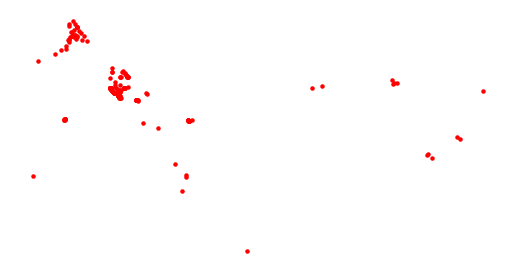

In [52]:
plt.figure(figsize=(10, 10), facecolor='white')
ax = gdf_earthquakes.plot(marker='o', color='red', markersize=5)
ax.set_axis_off()
plt.show()

Create interactive map

In [72]:
!pip install folium==0.12.1

  Obtaining dependency information for folium==0.12.1 from https://files.pythonhosted.org/packages/c3/83/e8cb37afc2f016a1cf4caab8d22caf7fe4156c4c15230d8abc9c83547e0c/folium-0.12.1-py2.py3-none-any.whl.metadata
  Obtaining dependency information for branca>=0.3.0 from https://files.pythonhosted.org/packages/17/ce/14166d0e273d12065516625fb02426350298e7b4ba59198b5fe454b46202/branca-0.7.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 1.8 MB/s eta 0:00:00a 0:00:01


In [ ]:
map = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')

#Loop 
for index, row in df_earthquakes.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=row['magnitude'] * 2,  # Example: scale radius by magnitude for visualization
        popup=f"Magnitude: {row['magnitude']}\nDepth: {row['depth']}",
        color='red',
        fill=True,
        fill_color='red'
    ).add_to(map)


In [ ]:
# Display the map
map

Largest earth Quakes in past 30 days: 

In [ ]:
#significant earthquakes in the past 30 days
url = 'https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/significant_month.geojson'

# Fetch the data
response = requests.get(url)
data = response.json()

# Extract earthquake data
earthquakes = data['features']

# Parse earthquake data into a DataFrame
rows = []
for eq in earthquakes:
    magnitude = eq['properties']['mag']
    latitude = eq['geometry']['coordinates'][1]
    longitude = eq['geometry']['coordinates'][0]
    rows.append({'magnitude': magnitude, 'latitude': latitude, 'longitude': longitude})

df_earthquakes = pd.DataFrame(rows)


In [ ]:
df_earthquakes.head()

Largest earthQuakes by magnitude

In [ ]:
# Sort by magnitude in descending order and select the top 5
largest_earthquakes = df_earthquakes.sort_values(by='magnitude', ascending=False).head(5)

#top 5 largest earthquakes
print(largest_earthquakes)

In [ ]:
map = folium.Map(location=[20, 0], zoom_start=2, tiles='OpenStreetMap')

#markers for the top 5 largest earthquakes
for index, row in largest_earthquakes.iterrows():
    folium.Marker(
        location=[row['latitude'], row['longitude']],
        popup=f"Magnitude: {row['magnitude']}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(map)

#the map to an HTML file
map.save('largest_earthquakes_map.html')

'largest_earthquakes_map.html'

In [ ]:
# Feature selection: Selecting relevant features for the model
X = df_earthquakes[['latitude', 'longitude', 'depth']]  # Input features
y = df_earthquakes['magnitude']  # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#model
model = LinearRegression()

#
model.fit(X_train, y_train)

In [ ]:
# Predicting the magnitudes on the test
y_pred = model.predict(X_test)

#Root Mean Squared Error (RMSE)
rmse = sqrt(mean_squared_error(y_test, y_pred))

print(f'Root Mean Squared Error: {rmse}')

In [ ]:
#scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
#model
ridge_model = Ridge()

#parameters grid
parameters = {'alpha': [1e-15, 1e-10, 1e-5, 1, 5, 10, 20]}

#grid search
ridge_regressor = GridSearchCV(ridge_model, parameters, scoring='neg_mean_squared_error', cv=5)
ridge_regressor.fit(X_train, y_train)

# Best parameters& RMSE
print(f'Best Parameters: {ridge_regressor.best_params_}')
best_rmse = sqrt(-ridge_regressor.best_score_)
print(f'Best RMSE: {best_rmse}')